# Batch evaluate and visualize results on Azure AI Foundry
Batch evaluate to leverage asynchronous evaluation on a dataset.<br/>
**Tool Call Accuracy** and **Task Adherence** evaluators will be analyzed in this batch, and then saved locally and then into the Foundry Project.

Optionally, you can go to AI Foundry URL for rich Azure AI Foundry data visualization. You can inspect the evaluation scores and reasoning to quickly identify bugs and issues of your agent to fix and improve. Make sure to authenticate to Azure using `az login` in your terminal before running this cell.

**IMPORTANT**: The output is visible in the Foundry Classic interface only.
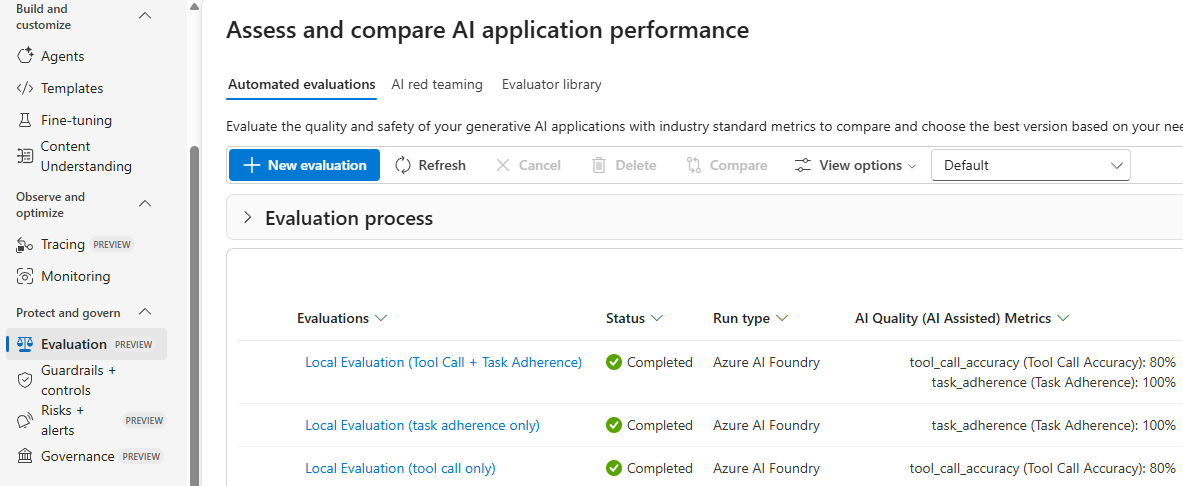

## Variables, Constants and Libraries definition

In [1]:
import os, sys
from dotenv import load_dotenv  # requires python-dotenv
from azure.identity import DefaultAzureCredential

if not load_dotenv():
    print("Environment variables not loaded, cell execution stopped")
    sys.exit()

openai_api_version = os.environ["AZURE_OPENAI_API_VERSION"]
azure_openai_endpoint = os.environ["AZURE_OPENAI_ENDPOINT"]
foundry_project_endpoint = os.environ.get("FOUNDRY_PROJECT_ENDPOINT")

# gpt-4.1-mini is the latest working model because later models require max_completion_tokens, while this evaluator sends max_tokens
azure_evaluation_compatible_deployment_name = os.environ[
    "AZURE_OPENAI_EVALUATION_COMPATIBLE_DEPLOYMENT_NAME"
]

credential = DefaultAzureCredential(
    exclude_environment_credential=True
)

print(f"azure_openai_endpoint: {azure_openai_endpoint}")
print(f"foundry_project_endpoint: {foundry_project_endpoint}")
print(f"azure_evaluation_compatible_deployment_name: {azure_evaluation_compatible_deployment_name}")
print(f"openai_api_version: {openai_api_version}")

azure_openai_endpoint: https://mm-ai-upskilling-project-resourc.openai.azure.com/
foundry_project_endpoint: https://mm-ai-upskilling-project-resourc.services.ai.azure.com/api/projects/ai-upskilling-project
azure_evaluation_compatible_deployment_name: gpt-4.1-mini
openai_api_version: 2025-04-01-preview


### Initialize `Tool Call Accuracy` + `Task Adherence` Evaluators

In [2]:
from azure.ai.evaluation import ToolCallAccuracyEvaluator, TaskAdherenceEvaluator, AzureOpenAIModelConfiguration
from pprint import pprint
import warnings

warnings.filterwarnings("ignore")

model_config = AzureOpenAIModelConfiguration(
    azure_endpoint=azure_openai_endpoint,
    azure_deployment=azure_evaluation_compatible_deployment_name,
    api_version=openai_api_version,
)

tool_call_accuracy       = ToolCallAccuracyEvaluator(model_config,credential=credential)

task_adherence_evaluator = TaskAdherenceEvaluator(model_config, credential=credential)

# Print some constants
print(f'openai endpoint: <{model_config["azure_endpoint"]}>')
print(f'azure deployment name: <{model_config["azure_deployment"]}>')
print(f'openai api version: <{model_config["api_version"]}>')

Class ToolCallAccuracyEvaluator: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class TaskAdherenceEvaluator: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.


openai endpoint: <https://mm-ai-upskilling-project-resourc.openai.azure.com/>
azure deployment name: <gpt-4.1-mini>
openai api version: <2025-04-01-preview>


## Batch evaluate and visualize results on Azure AI Foundry
Batch evaluate to leverage asynchronous evaluation on a dataset. 

Optionally, you can go to AI Foundry URL for rich Azure AI Foundry data visualization. You can inspect the evaluation scores and reasoning to quickly identify bugs and issues of your agent to fix and improve. Make sure to authenticate to Azure using `az login` in your terminal before running this cell.

In [3]:
from pathlib import Path
from azure.ai.evaluation import evaluate

# Keep this False for a local batch run. Set it to True to also publish the results to Foundry.
publish_to_foundry = True

project_endpoint = (
    foundry_project_endpoint.strip() or None
    if publish_to_foundry and foundry_project_endpoint
    else None
)

if publish_to_foundry and not project_endpoint:
    raise ValueError(
        "FOUNDRY_PROJECT_ENDPOINT must be set when publish_to_foundry is True."
    )

data_path = Path("evaluation_data.jsonl")
output_path = Path("evaluation_results/ToolCall_and_TaskAdherence.json")
output_path.parent.mkdir(parents=True, exist_ok=True)

response = evaluate(
    data=data_path,
    evaluation_name="Local Evaluation (Tool Call + Task Adherence)",
    evaluators={
        "tool_call_accuracy": tool_call_accuracy,
        "task_adherence": task_adherence_evaluator,
    },
    azure_ai_project=project_endpoint,
    credential=credential,
    output_path=output_path,
)

# restore output_path to stdout
import sys
(type(sys.stdout).__module__, type(sys.stdout).__name__)

while hasattr(sys.stdout, "_prev_out"):
    sys.stdout = sys.stdout._prev_out

while hasattr(sys.stderr, "_prev_out"):
    sys.stderr = sys.stderr._prev_out

print(f"Local results: {output_path.resolve()}")
studio_url = response.get("studio_url")

if studio_url:
    print(f"Microsoft Foundry URL (to be checked on the classic Foundry portal): {studio_url}")

2026-09-12 17:14:49 +0200 134170213447360 execution          WARNING  [NodeInfo(run_id='task_adherence_20260912_151447_172684', node_name='Flex', line_number=2)] stderr> Conversation history could not be parsed; falling back to raw input. Evaluator accuracy will degrade. Input shape: type=list len=14 roles=['system', 'user', 'assistant', 'tool', 'assistant', 'user', 'assistant', 'tool', 'assistant', 'user']. Error: (UserError) ErrorMessage.MALFORMED_CONVERSATION_HISTORY
2026-09-12 17:14:50 +0200 134170221840064 execution.bulk     INFO     Finished 1 / 5 lines.
2026-09-12 17:14:50 +0200 134170221840064 execution.bulk     INFO     Average execution time for completed lines: 3.55 seconds. Estimated time for incomplete lines: 14.2 seconds.
2026-09-12 17:14:55 +0200 134170213447360 execution.bulk     INFO     Finished 1 / 5 lines.
2026-09-12 17:14:55 +0200 134170213447360 execution.bulk     INFO     Average execution time for completed lines: 8.76 seconds. Estimated time for incomplete line

Aggregated metrics for evaluator is not a dictionary will not be logged as metrics
Aggregated metrics for evaluator is not a dictionary will not be logged as metrics


======= Run Summary =======

Run name: "tool_call_accuracy_20260912_151447_175929"
Run status: "Completed"
Start time: "2026-09-12 15:14:47.175929+00:00"
Duration: "0:00:11.017493"

======= Combined Run Summary (Per Evaluator) =======

{
    "tool_call_accuracy": {
        "status": "Completed",
        "duration": "0:00:11.017493",
        "completed_lines": 5,
        "failed_lines": 0,
        "log_path": null,
        "per_line_errors": {},
        "error_message": null,
        "error_code": null
    },
    "task_adherence": {
        "status": "Completed",
        "duration": "0:00:10.076270",
        "completed_lines": 5,
        "failed_lines": 0,
        "log_path": null,
        "per_line_errors": {},
        "error_message": null,
        "error_code": null
    }
}


Evaluation results saved to "/home/mauromi/git_repos/microsoft-ai-upskilling/02-microsoft-evaluation-platform/samples/2 - local evaluation/evaluation_results/ToolCall_and_TaskAdherence.json".

Local results: /ho